In [9]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from matplotlib import pyplot as plt

In [10]:
service = QiskitRuntimeService()

In [11]:
backend = service.least_busy(simulator=False, operational=True)
print(f"Trageting Backend: {backend.name}")
print("Backend version:", backend.version)
print("Number of qubits:", backend.num_qubits)

Trageting Backend: ibm_fez
Backend version: 2
Number of qubits: 156


In [12]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

qc.measure_all()


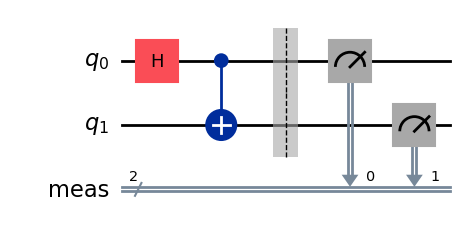

In [13]:
qc.draw(output='mpl', style='iqp')

In [14]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

isa_circuit = pm.run(qc)

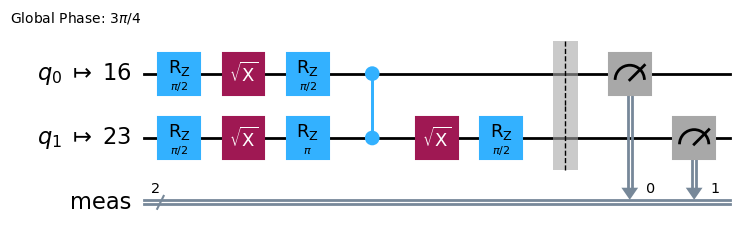

In [15]:
isa_circuit.draw(output='mpl', idle_wires=False)

In [17]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 4096

print(f"Submitting Job for {qc.name}...")
job = sampler.run([isa_circuit])

Submitting Job for circuit-42...


Measurement Outcomes: {'00': 2057, '11': 1945, '01': 47, '10': 47}


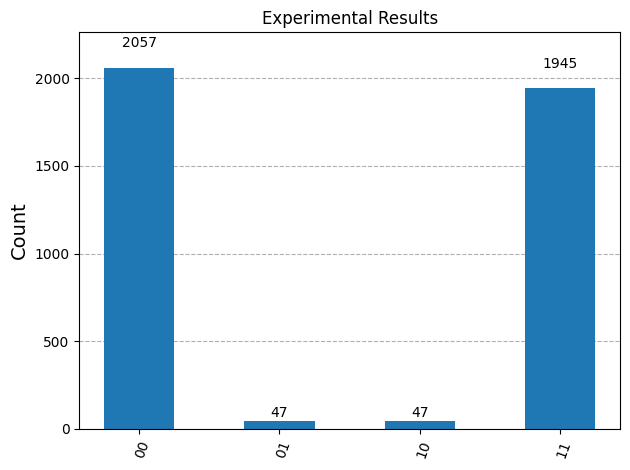

In [18]:
result = job.result()

counts = result[0].data.meas.get_counts()

print(f"Measurement Outcomes: {counts}")
plot_histogram(counts, title="Experimental Results")